In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
cd ../..

/


In [3]:
!pip install matplotlib_scalebar

In [4]:
import sys, os
save_dir = '/content/drive/MyDrive/Colab Notebooks/MR MCD Pipeline/results/Recon_InP_CuCrS2P6_70/'
os.makedirs(save_dir, exist_ok=True)
PROJECT_ROOT = "/content/drive/MyDrive/Colab Notebooks/MR MCD Pipeline/2D"

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)
    print("Added to sys.path:", PROJECT_ROOT)

print("Project root content:", os.listdir(PROJECT_ROOT))

Added to sys.path: /content/drive/MyDrive/Colab Notebooks/MR MCD Pipeline/2D
Project root content: ['Notebooks', 'data', 'Magnetisation']


In [5]:
from Magnetisation.Propagator import Propagator
from Magnetisation.Generator import generator_CNN
from Magnetisation.Train import Magnetisation_CNN_training
from Magnetisation.utils import LoadData

import numpy as np
import json
import torch
import matplotlib.pyplot as plt

In [6]:
import numpy as np
# 兼容补丁 / Compatibility patch
if not hasattr(np, "int"):
  np.int = int

[[ 3.94336766e-06 -6.07115250e-06  1.22681104e-05 ... -5.88175851e-06
   1.44587401e-05 -6.67861589e-06]
 [-1.16785474e-05  5.93845674e-06 -3.46556504e-06 ... -2.26819256e-05
   2.89130931e-05  2.63516225e-05]
 [-1.05259909e-05 -2.48646712e-05  3.56762230e-06 ... -1.00370835e-05
  -1.28770884e-05  1.12021632e-05]
 ...
 [-3.54951342e-05 -1.23828046e-05  3.37599918e-05 ... -3.05581326e-05
  -5.11515139e-05  2.47953028e-05]
 [-4.25775528e-05  1.34110128e-05  1.14523178e-05 ... -1.82521578e-05
   2.56685707e-05 -6.11408293e-06]
 [-4.81065840e-05 -3.26336714e-05 -1.07344163e-04 ... -5.52006571e-05
   2.26014354e-05 -1.30605252e-05]]
[[ 3.94336766e-06 -6.07115250e-06  1.22681104e-05 ... -5.88175851e-06
   1.44587401e-05 -6.67861589e-06]
 [-1.16785474e-05  5.93845674e-06 -3.46556504e-06 ... -2.26819256e-05
   2.89130931e-05  2.63516225e-05]
 [-1.05259909e-05 -2.48646712e-05  3.56762230e-06 ... -1.00370835e-05
  -1.28770884e-05  1.12021632e-05]
 ...
 [-3.54951342e-05 -1.23828046e-05  3.3759991

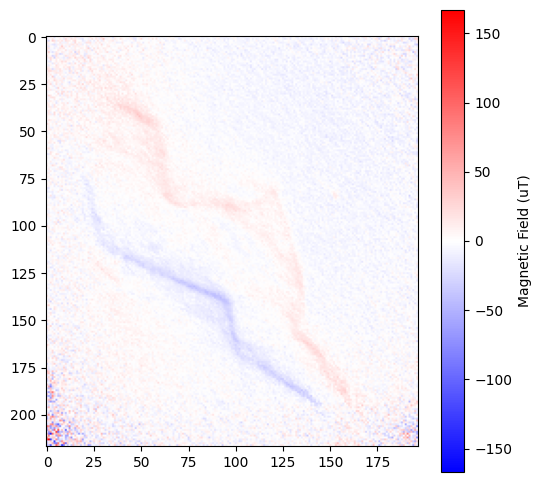

{'PixelSize': 4.8e-07,
 'ImageShape': 256,
 'NV': {'Height': 3e-07,
  'Theta': 0,
  'FindTheta': False,
  'Phi': 0,
  'FindPhi': False},
 'Magnetisation': {'Phi': -45,
  'FindPhi': False,
  'Theta': 90,
  'FindTheta': False},
 'FFT': {'PaddingFactor': 2,
  'performPadding': False,
  'PaddingMode': 'constant',
  'Extended': False,
  'Extention': 100,
  'Filter': {'useHanning': False,
   'useHighCutoff': False,
   'useLowCutoff': False,
   'LambdaHighCutoff': 1e-07,
   'LambdaLowCutoff': 7e-06}}}

In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# Load data
dataPath='/content/drive/MyDrive/Colab Notebooks/MR MCD Pipeline/2D/data/Magnetisation in plane/CuCrP2S6_unimelb_measurement_70_Bnv.json'
PROP = LoadData(dataPath, ImageShape = 256, Normalise=True, Display=True)
plt.savefig(save_dir + '1_input_magnetic_field.png', dpi=300, bbox_inches='tight')
plt.show()
# Update some of the options
PROP.options['Magnetisation']['Theta']= 90
PROP.options['Magnetisation']['FindTheta']= False
PROP.options['Magnetisation']['Phi'] = -45
PROP.options['Magnetisation']['FindPhi']= False
display(PROP.options)

In [12]:
# Make the neural network
Generator = generator_CNN(Size=1, ImageSize=PROP.options['ImageShape']).to(device)

In [13]:
# Set the machine learning paramaters for keyword unpacking
ML_options = dict()
ML_options['mlp']=False
ML_options['LossFunction']='L1'
ML_options['Magnetization']=None
ML_options['IntegerOnly']=False
ML_options['PositiveMagnetisationOnly']=True
ML_options['PrintLossValue']=False
ML_options['Epochs']= 150

100%|██████████| 150/150 [00:28<00:00,  5.26it/s]


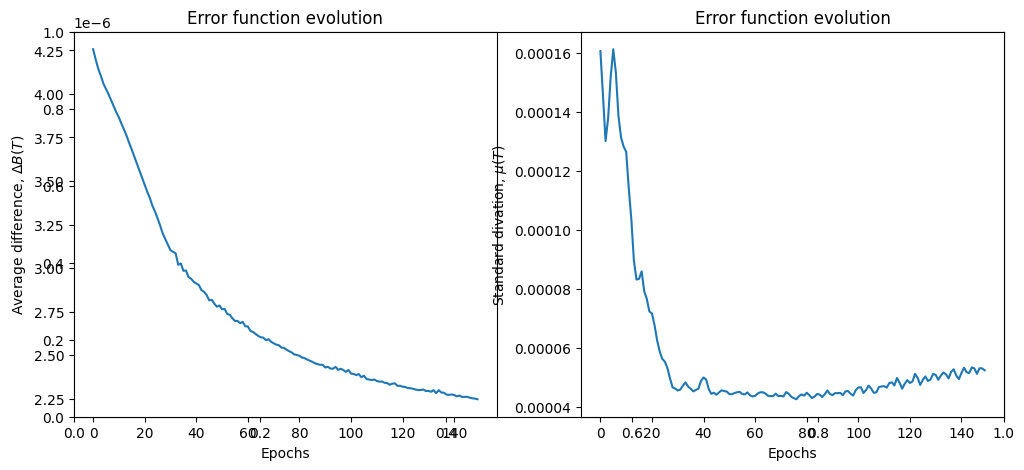

In [14]:
# Train the network
CNN_training = Magnetisation_CNN_training(device, Generator, PROP,ML_options)
bnv_cnn = CNN_training.train_cnn(**ML_options)
plt.savefig(save_dir + '2_training_loss.png', dpi=300, bbox_inches='tight')
plt.show()

Final MagnetisationMap shape: (256, 256)
Final ReconstructedBnv shape: (256, 256)


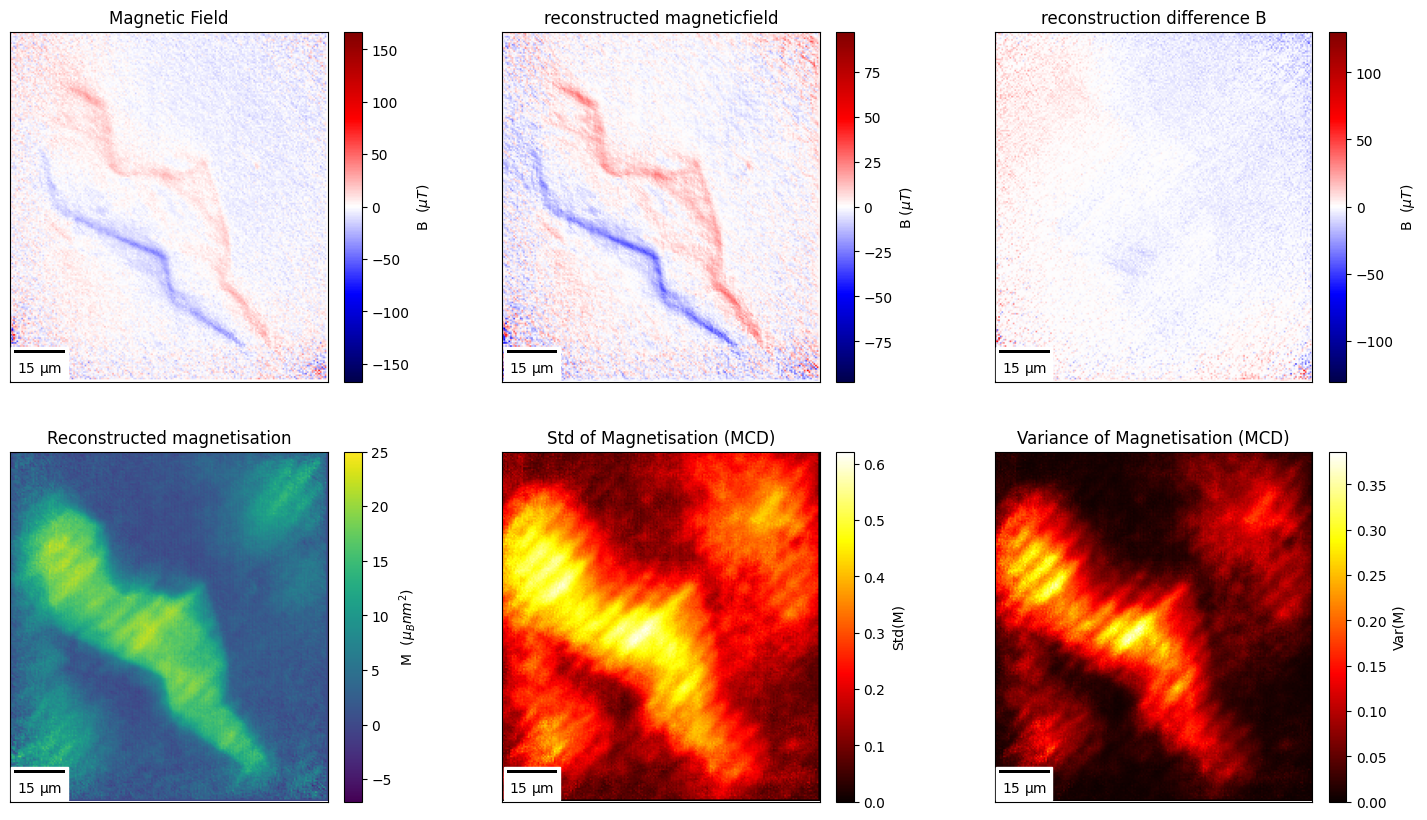

In [15]:
# Get the results and plot
Results = CNN_training.extract_results(plotResults = True)
plt.savefig(save_dir + '3_reconstruction_results.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
from Magnetisation.utils import SaveDictToJson
# SaveDictToJson("B_Reconstruction_dataset_70_mlp", Results)